# Lab Segmentation 2

In [4]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def getThreshold(gray_img: np.ndarray):
    img = gray_img.copy()
    img = (img * 255).astype(np.uint8)  # 1: Convert to uint8

    # 2: Get counts array (number of pixels per grey-level)
    counts = np.unique(img.flatten(), return_counts=True)
    grey_levels = counts[0]
    pixel_counts = counts[1]
    
    # 3: Get initial threshold Tinit
    weighted_sum = np.sum(grey_levels * pixel_counts)
    cumsum = np.cumsum(pixel_counts)
    total_pixels = cumsum[-1]
    T = round(weighted_sum / total_pixels)
    
    # 6: Repeat until threshold saturates
    while True:
        # 4: Get the two weighted averages
        lower_mask = grey_levels < T
        lower_levels = grey_levels[lower_mask]
        lower_counts = pixel_counts[lower_mask]
        if len(lower_counts) > 0:
            lower_mean = np.sum(lower_levels * lower_counts) / np.sum(lower_counts)
        else:
            lower_mean = 0
        
        higher_mask = grey_levels > T
        higher_levels = grey_levels[higher_mask]
        higher_counts = pixel_counts[higher_mask]
        if len(higher_counts) > 0:
            higher_mean = np.sum(higher_levels * higher_counts) / np.sum(higher_counts)
        else:
            higher_mean = 0
        
        # 5: Update new threshold to average of the two means
        new_T = round((lower_mean + higher_mean) / 2)
        
        # Check if saturated
        if new_T == T:
            break
        T = new_T
    
    return T

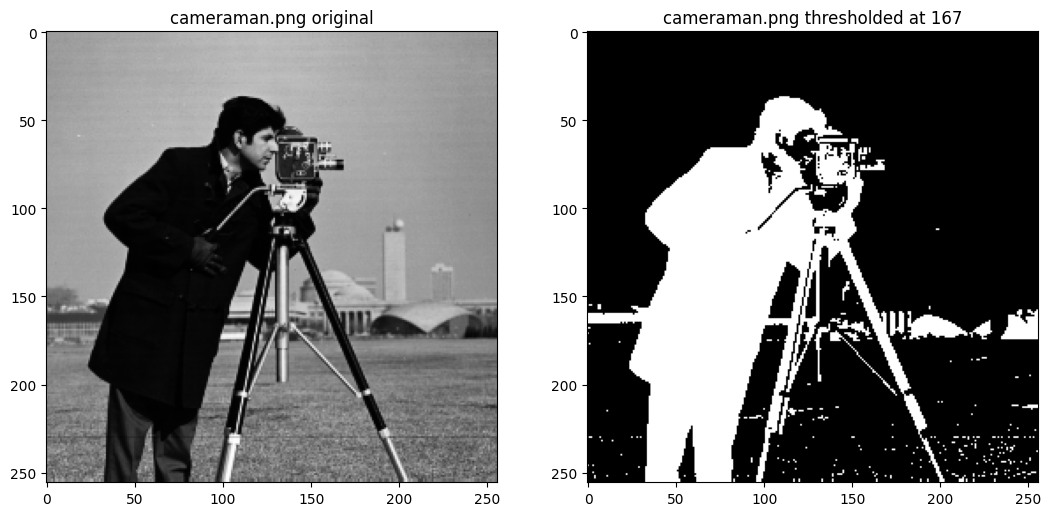

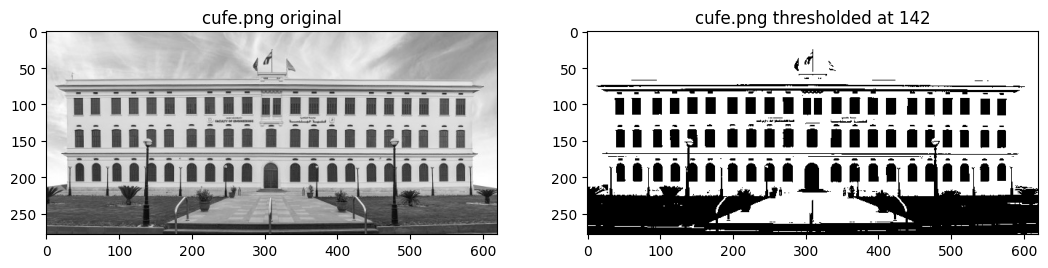

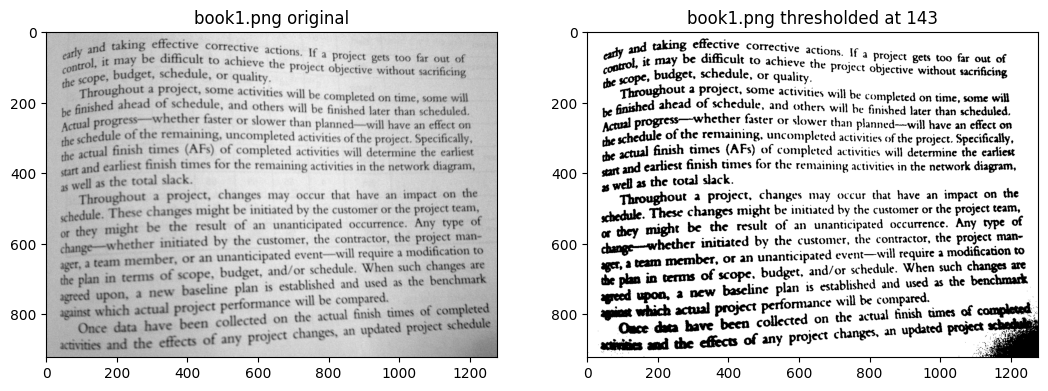

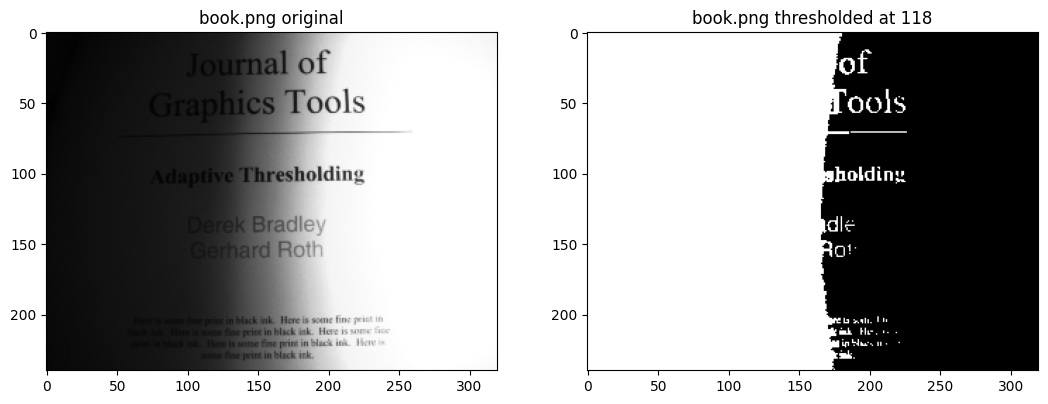

In [6]:
# Test the thresholding on the specified images
images = ['cameraman.png', 'cufe.png', 'book1.png', 'book.png']

for img_name in images:
    img = io.imread(img_name, as_gray=True)
    threshold = getThreshold(img)
    # Pixels < threshold -> 0, else 255
    binary_img = np.where(img * 255 < threshold, 0, 255).astype(np.uint8)
    show_images([img, binary_img], [f'{img_name} original', f'{img_name} thresholded at {threshold}'])

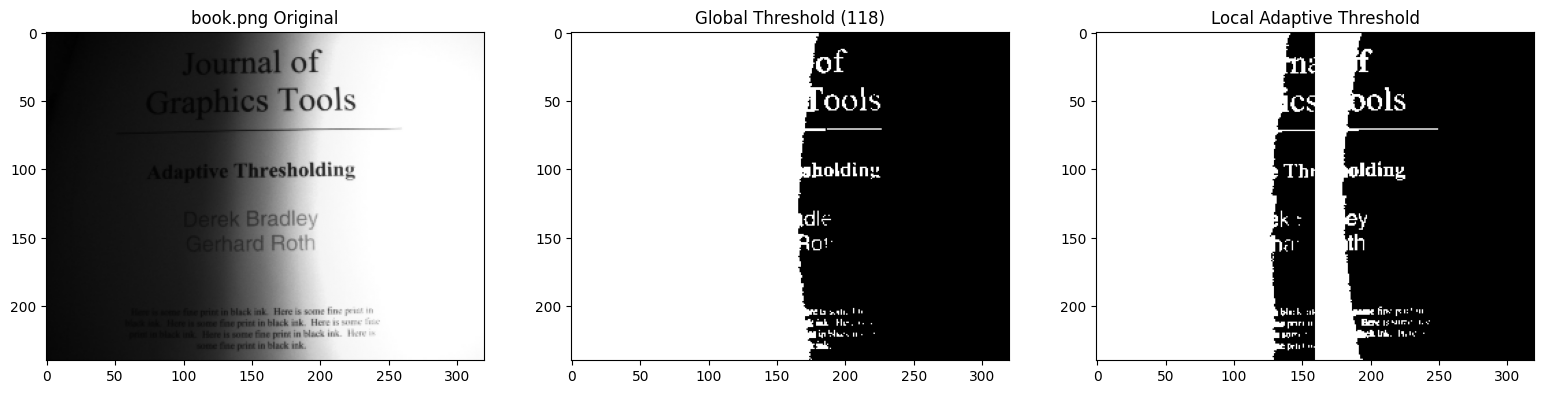

In [ ]:
# Experiment 2: Local adaptive thresholding on "book.png"
book_img = io.imread('book.png', as_gray=True)

# 1. Original image
# 2. Global thresholded
global_threshold = getThreshold(book_img)
global_binary = np.where(book_img * 255 < global_threshold, 0, 255).astype(np.uint8)

# Partition into four quarters
h, w = book_img.shape
h_half, w_half = h // 2, w // 2

quarters = [
    book_img[:h_half, :w_half],      # Top-left
    book_img[:h_half, w_half:],      # Top-right
    book_img[h_half:, :w_half],      # Bottom-left
    book_img[h_half:, w_half:]       # Bottom-right
]

# Apply local threshold on each quarter
local_binary_quarters = []
for quarter in quarters:
    local_thresh = getThreshold(quarter)
    local_binary = np.where(quarter * 255 < local_thresh, 0, 255).astype(np.uint8)
    local_binary_quarters.append(local_binary)

# Gather the four quarters together
local_binary = np.zeros_like(book_img, dtype=np.uint8)
local_binary[:h_half, :w_half] = local_binary_quarters[0]
local_binary[:h_half, w_half:] = local_binary_quarters[1]
local_binary[h_half:, :w_half] = local_binary_quarters[2]
local_binary[h_half:, w_half:] = local_binary_quarters[3]

show_images([book_img, global_binary, local_binary],
            ['book.png Original', f'Global Threshold ({global_threshold})', 'Local Adaptive Threshold'])

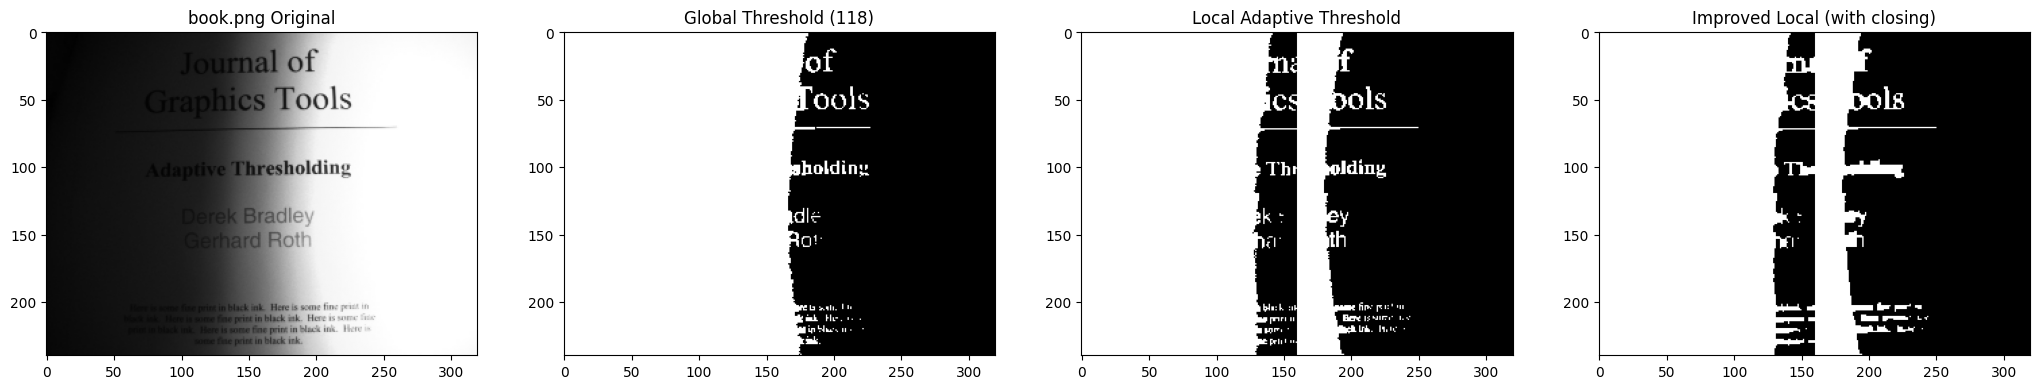

In [ ]:
from skimage.morphology import binary_closing

kernel = np.ones((3, 3), dtype=np.uint8)
improved_local_binary = binary_closing(local_binary.astype(bool), footprint=kernel).astype(np.uint8) * 255

show_images([book_img, global_binary, local_binary, improved_local_binary],
            ['book.png Original', f'Global Threshold ({global_threshold})', 'Local Adaptive Threshold', 'Improved Local (with closing)'])